In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create project folders (for Milestone 1 outputs)
os.makedirs("docs", exist_ok=True)
os.makedirs("outputs/cleaned", exist_ok=True)
os.makedirs("outputs/visuals", exist_ok=True)

print("Folders ready: docs/, outputs/cleaned/, outputs/visuals/")


Folders ready: docs/, outputs/cleaned/, outputs/visuals/


In [2]:
DATA_PATH = "customer_support_tickets.csv"  # change if needed

df = pd.read_csv(DATA_PATH)
print("Dataset Loaded!")
print("Shape (rows, cols):", df.shape)


Dataset Loaded!
Shape (rows, cols): (8469, 17)


In [3]:
df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
df.columns.tolist()


['Ticket ID',
 'Customer Name',
 'Customer Email',
 'Customer Age',
 'Customer Gender',
 'Product Purchased',
 'Date of Purchase',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Description',
 'Ticket Status',
 'Resolution',
 'Ticket Priority',
 'Ticket Channel',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating']

In [7]:
df.info()
missing = df.isna().sum().sort_values(ascending=False)
missing.head(25)
with open("docs/schema_missing_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Dataset shape: {df.shape}\n\n")
    f.write("Columns:\n" + "\n".join(df.columns.astype(str)) + "\n\n")
    f.write("Data types:\n" + df.dtypes.to_string() + "\n\n")
    f.write("Missing values:\n" + missing.to_string() + "\n")

print("Saved: docs/schema_missing_report.txt")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [8]:
df_clean = df.drop_duplicates().copy()

# Strip whitespace from object columns
for c in df_clean.columns:
    if df_clean[c].dtype == "object":
        df_clean[c] = df_clean[c].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

print("After cleaning shape:", df_clean.shape)
df_clean.head()


After cleaning shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [9]:
key_cols = ["Ticket Type", "Ticket Priority", "Product Purchased"]
for c in key_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna("Unknown")

df_clean[key_cols].isna().sum()


Ticket Type          0
Ticket Priority      0
Product Purchased    0
dtype: int64

In [10]:
df_clean["First Response Time"] = pd.to_datetime(df_clean["First Response Time"], errors="coerce")
df_clean["Time to Resolution"]  = pd.to_datetime(df_clean["Time to Resolution"], errors="coerce")

df_clean[["First Response Time", "Time to Resolution"]].head()


,First Response Time,Time to Resolution
0,2023-06-01 12:15:36,NaT
1,2023-06-01 16:45:38,NaT
2,2023-06-01 11:14:38,2023-06-01 18:05:38
3,2023-06-01 07:29:40,2023-06-01 01:57:40
4,2023-06-01 00:12:42,2023-06-01 19:53:42


In [11]:
priority_map = {"critical": 4, "high": 3, "medium": 2, "low": 1}

df_clean["Priority_Score"] = (
    df_clean["Ticket Priority"].astype(str).str.lower().map(priority_map)
)

df_clean[["Ticket Priority", "Priority_Score"]].head(10)
df_clean["Resolution_Duration_Hours"] = (
    (df_clean["Time to Resolution"] - df_clean["First Response Time"]).dt.total_seconds() / 3600
)

df_clean["Resolution_Duration_Hours"].describe()


count    2769.000000
mean       -0.057704
std         9.564112
min       -23.233333
25%        -6.933333
50%         0.166667
75%         6.483333
max        23.466667
Name: Resolution_Duration_Hours, dtype: float64

In [12]:
df_clean.to_csv("outputs/cleaned/cleaned_tickets.csv", index=False)
print("Saved: outputs/cleaned/cleaned_tickets.csv")


Saved: outputs/cleaned/cleaned_tickets.csv


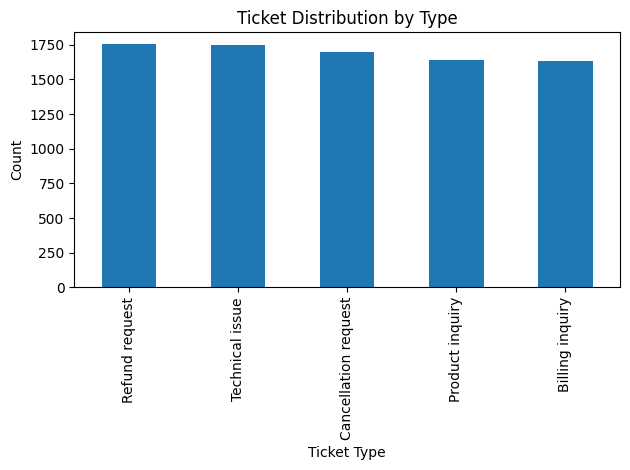

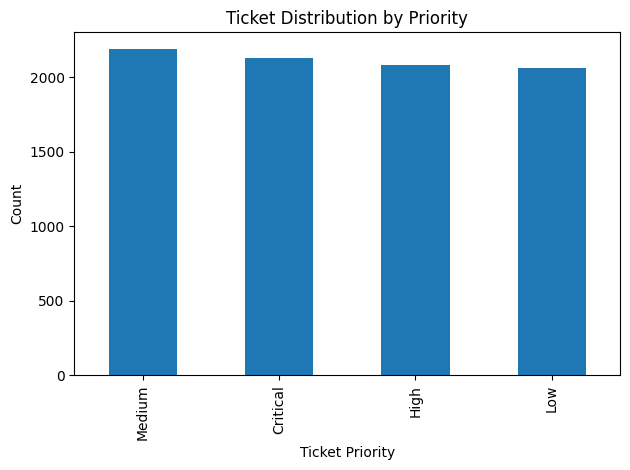

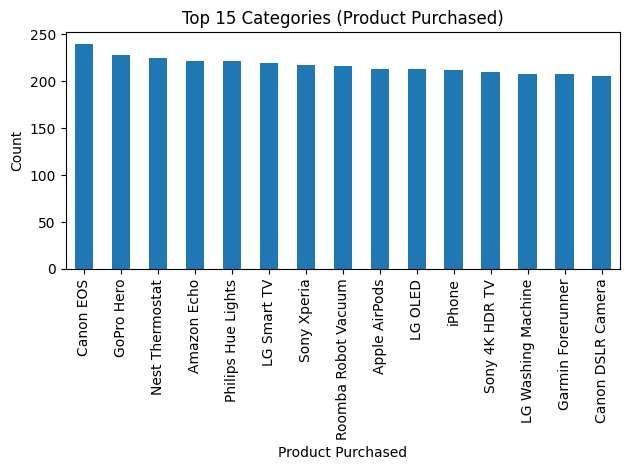

In [14]:
df_clean["Ticket Type"].value_counts().plot(kind="bar")
plt.title("Ticket Distribution by Type")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/ticket_type_distribution.png", dpi=200)
plt.show()
df_clean["Ticket Priority"].value_counts().plot(kind="bar")
plt.title("Ticket Distribution by Priority")
plt.xlabel("Ticket Priority")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/priority_distribution.png", dpi=200)
plt.show()
df_clean["Product Purchased"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Categories (Product Purchased)")
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/category_distribution.png", dpi=200)
plt.show()


In [15]:
with open("docs/data_dictionary.md", "w", encoding="utf-8") as f:
    f.write("# Data Dictionary\n\n")
    f.write("| Column | Data Type |\n|---|---|\n")
    for col in df_clean.columns:
        f.write(f"| `{col}` | `{df_clean[col].dtype}` |\n")

print("Saved: docs/data_dictionary.md")
with open("docs/feature_summary.md", "w", encoding="utf-8") as f:
    f.write("# Feature Engineering Summary (Milestone 1)\n\n")
    f.write("## Cleaning Steps\n")
    f.write("- Removed duplicate rows\n")
    f.write("- Stripped whitespace from text columns\n")
    f.write("- Filled missing values for Ticket Type, Ticket Priority, Product Purchased\n")
    f.write("- Converted First Response Time and Time to Resolution columns to datetime\n\n")
    f.write("## New Features\n")
    f.write("- `Priority_Score`: mapped from Ticket Priority (Critical=4, High=3, Medium=2, Low=1)\n")
    f.write("- `Resolution_Duration_Hours`: (Time to Resolution - First Response Time) in hours\n")

print("Saved: docs/feature_summary.md")


Saved: docs/data_dictionary.md
Saved: docs/feature_summary.md
